#### Матрицы ошибок и отчет по класификации

In [1]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
churn_df = pd.read_csv('telecom_churn_clean.csv')
X = churn_df.drop('churn', axis=1).values
y = churn_df['churn'].values
knn = KNeighborsClassifier(n_neighbors=7)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print(confusion_matrix(y_test, y_pred))

[[566   4]
 [ 89   8]]


In [2]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.99      0.92       570
           1       0.67      0.08      0.15        97

    accuracy                           0.86       667
   macro avg       0.77      0.54      0.54       667
weighted avg       0.84      0.86      0.81       667



#### Логистическая регрессия

In [3]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [4]:
y_pred_probs = logreg.predict_proba(X_test)[:, 1]
print(y_pred_probs[:10])

[0.13224128 0.11581493 0.02384258 0.10850702 0.19820185 0.03197688
 0.34895611 0.11095836 0.06598902 0.09359155]


#### ROC-кривая

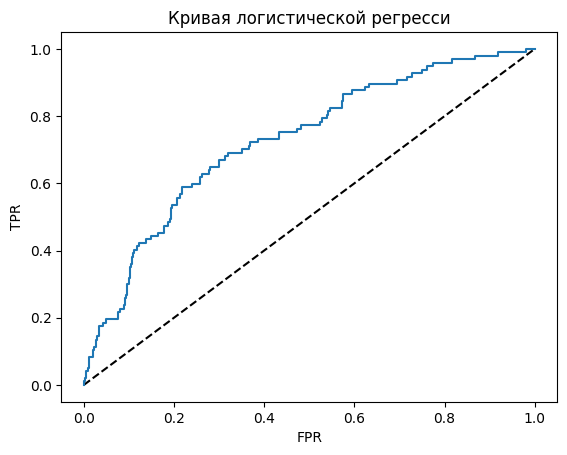

In [5]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, tresholds = roc_curve(y_test, y_pred_probs)
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Кривая логистической регресси')
plt.show()

In [6]:
print(roc_auc_score(y_test, y_pred_probs))

0.7264966540061494


#### Поиск по сетке гиперапареметров

In [18]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import Ridge
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'alpha': np.geomspace(0.0001, 1000, num=20),
              'solver': ["sag", "lsqr"]}
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv=kf)
ridge_cv.fit(X_train, y_train)
print(ridge_cv.best_params_, ridge_cv.best_score_)


/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

{'alpha': 78.47599703514607, 'solver': 'lsqr'} 0.1109108156706029


In [21]:
from sklearn.model_selection import RandomizedSearchCV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {'alpha': np.geomspace(0.0001, 1000, num=20),
              'solver': ["sag", "lsqr"]}
ridge = Ridge()
ridge_cv = RandomizedSearchCV(ridge, param_grid, cv=kf, n_iter=10)
ridge_cv.fit(X_train, y_train)
print(ridge_cv.best_params_, ridge_cv.best_score_)

/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was

{'solver': 'lsqr', 'alpha': 33.59818286283781} 0.11088494409402368
